# Model Comparison

Comparison of the tuned Decision Tree and tuned Random Forest models using their final test-set performance.

In [3]:
# Import pandas and define the checkpoint folder used by the previous model notebooks

from pathlib import Path
import pandas as pd

import matplotlib.pyplot as plt

checkpoint_dir = Path("../checkpoints")

print("Decision Tree results:",
      (checkpoint_dir / "05_decision_tree_final_test.txt").exists())

print("Random Forest results:",
      (checkpoint_dir / "10_random_forest_final_test.txt").exists())

Decision Tree results: True
Random Forest results: True


In [2]:
# Read the saved final test metrics and create a Decision Tree vs Random Forest comparison table

def read_metrics(file_path):
    metrics = {}

    with open(file_path, "r") as f:
        for line in f:
            for metric in ["Accuracy", "Precision", "Sensitivity", "Specificity", "ROC-AUC"]:
                if line.startswith(metric + ":"):
                    metrics[metric] = float(line.split(":")[1].strip())

    return metrics


decision_tree_results = read_metrics(
    checkpoint_dir / "05_decision_tree_final_test.txt"
)

random_forest_results = read_metrics(
    checkpoint_dir / "10_random_forest_final_test.txt"
)

model_comparison = pd.DataFrame({
    "Decision Tree": decision_tree_results,
    "Random Forest": random_forest_results
})

model_comparison["Difference"] = (
    model_comparison["Random Forest"] -
    model_comparison["Decision Tree"]
)

print(model_comparison.round(4))

             Decision Tree  Random Forest  Difference
Accuracy            0.9556         0.9631      0.0075
Precision           0.9629         0.9711      0.0082
Sensitivity         0.9348         0.9440      0.0092
Specificity         0.9718         0.9780      0.0062
ROC-AUC             0.9847         0.9941      0.0094


### Final Model Performance Comparison

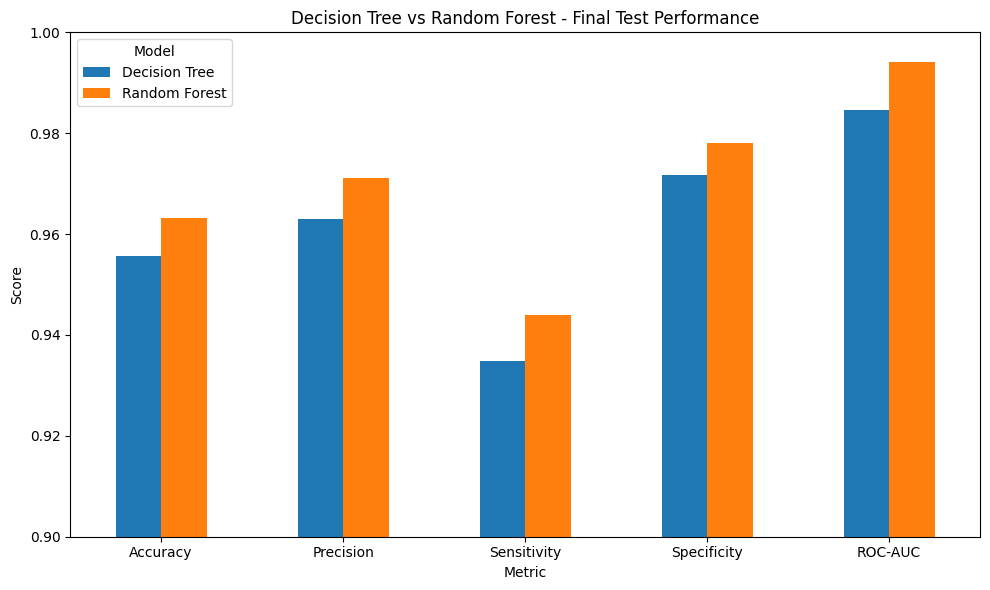

In [4]:
# Plot the final test performance of the Decision Tree and Random Forest

plot_data = model_comparison[["Decision Tree", "Random Forest"]]

ax = plot_data.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.ylabel("Score")
plt.xlabel("Metric")
plt.title("Decision Tree vs Random Forest - Final Test Performance")
plt.ylim(0.90, 1.00)
plt.xticks(rotation=0)
plt.legend(title="Model")
plt.tight_layout()
plt.show()

In [5]:
# Save the final Decision Tree vs Random Forest comparison for later use in the report

with open(checkpoint_dir / "11_final_model_comparison.txt", "w") as f:
    f.write("FINAL MODEL COMPARISON - TEST SET\n\n")
    f.write(model_comparison.to_string())

print("Saved: 11_final_model_comparison.txt")

Saved: 11_final_model_comparison.txt
